In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
rej = pd.read_csv('/content/drive/MyDrive/rejected_loans_with_predictions.csv')  # replace with your path
rej.head()


,loan_title,default_prob,risk_category
0,Wedding Covered but No Honeymoon,0.115299,Medium
1,Consolidating Debt,0.089294,Low
2,Want to consolidate my debt,0.123505,Medium
3,waksman,0.254053,High
4,mdrigo,0.148081,Medium


In [ ]:
bins = [0, 0.3, 0.5, 0.7, 1.0]
labels = ['Low', 'Medium', 'High', 'Very High']
rej['risk_category'] = pd.cut(rej['default_prob'], bins=bins, labels=labels)
rej['risk_category'].value_counts()


,count
risk_category,
Low,700781
Medium,294262
High,4936
Very High,0


In [ ]:
top_risky = rej.groupby(['loan_title', 'risk_category'])['default_prob'] \
               .mean().reset_index().sort_values('default_prob', ascending=False)
top_risky.head(10)


/tmp/ipython-input-3133179102.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_risky = rej.groupby(['loan_title', 'risk_category'])['default_prob'] \


,loan_title,risk_category,default_prob
166226,UNSECURED,High,0.589635
158134,TUITION,High,0.581470
206070,jk6885,High,0.581172
207870,kg3,High,0.577999
81370,Increasing credit card rate is killing u,High,0.573421
237106,student loan,High,0.560407
166170,UGH!!! DEBT!!!,High,0.556304
30646,Consolidate Debts,High,0.548516
198998,goodfellas,High,0.548111
33774,Consolidation Loan,High,0.543608


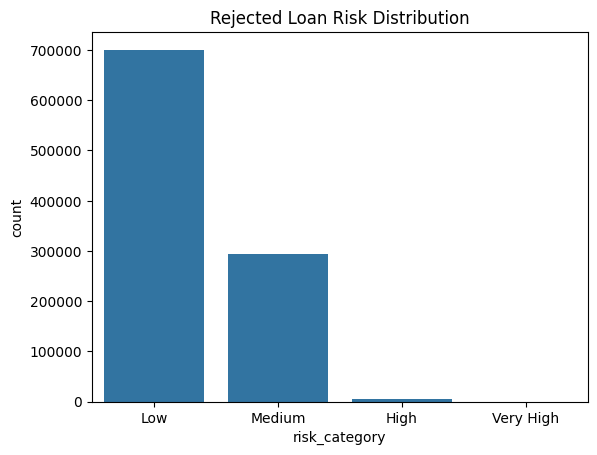

In [ ]:
sns.countplot(data=rej, x='risk_category', order=labels)
plt.title("Rejected Loan Risk Distribution")
plt.show()


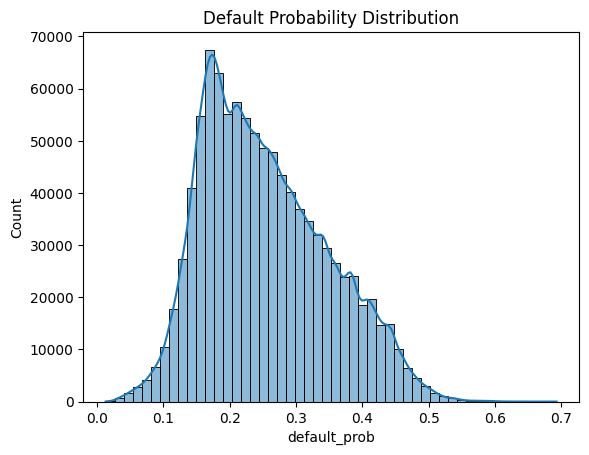

In [ ]:
sns.histplot(rej['default_prob'], bins=50, kde=True)
plt.title("Default Probability Distribution")
plt.show()


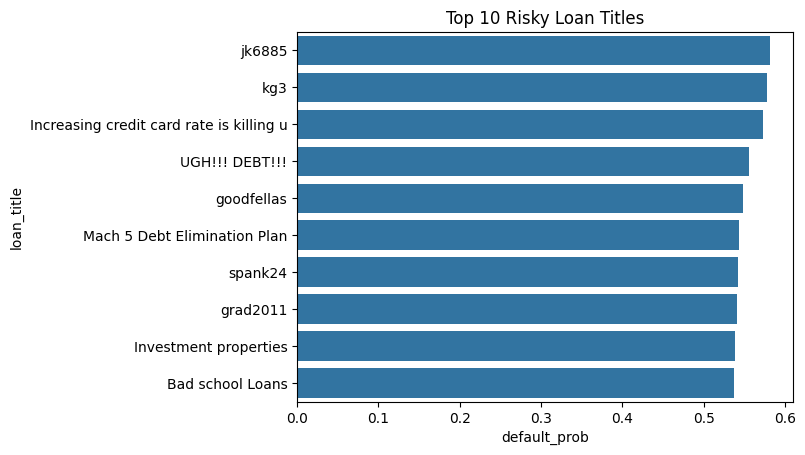

In [ ]:
top10 = top_risky.groupby('loan_title')['default_prob'].mean().nlargest(10).reset_index()
sns.barplot(data=top10, x='default_prob', y='loan_title')
plt.title("Top 10 Risky Loan Titles")
plt.show()


In [ ]:
rej.to_csv('rej_predictions_with_risk.csv', index=False)
top10.to_csv('top10_risky_loans.csv', index=False)
